## 1. Confirm Kaggle Input Path

This cell walks `/kaggle/input` to print the exact mounted file paths for the trained 
models and held-out test set exported by the [Email model training notebook](https://www.kaggle.com/code/azimehobadiah/email-xgb-rf-model-training). 
Add that notebook's output as an input to this notebook via **+ Add Input** before running 
(select "Notebook Output Files" and pick the training notebook), then re-run this cell to 
confirm the files are visible.

In [1]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/azimehobadiah/email-phishing-test-set/X_test_email.csv
/kaggle/input/datasets/azimehobadiah/email-phishing-test-set/y_test_email.csv
/kaggle/input/models/azimehobadiah/xgb-email-phishing-model/other/default/1/xgb_model_email.joblib
/kaggle/input/models/azimehobadiah/rf-email-phising/scikitlearn/default/1/rf_model_email.joblib


## 2. Load Trained Models and Held-Out Test Set

Loads the tuned XGBoost and Random Forest models along with the exact `X_test`/`y_test` 
split produced during training — using the same split (rather than a fresh one) ensures 
evaluation reflects true held-out performance on data neither model has seen or been tuned 
against.

**Label convention for this dataset:** `1 = Phishing` is treated as 
the positive class throughout this notebook, matching the scoring convention used during 
training.

In [2]:
from pathlib import Path
import pandas as pd
import joblib

search_roots = [Path.cwd()]
if Path("/kaggle/input").exists():
    search_roots.append(Path("/kaggle/input"))

def find_file(filename):
    for root in search_roots:
        matches = list(root.glob(f"**/{filename}"))
        if matches:
            return matches[0]
    raise FileNotFoundError(
        f"{filename} not found. Confirm the Email training notebook's output "
        "is added as an input via '+ Add Input' in the right sidebar."
    )

xgb_model_path = find_file("xgb_model_email.joblib")
rf_model_path = find_file("rf_model_email.joblib")
xtest_path = find_file("X_test_email.csv")
ytest_path = find_file("y_test_email.csv")

print("Loading models and test set from:")
print(" ", xgb_model_path)
print(" ", rf_model_path)
print(" ", xtest_path)
print(" ", ytest_path)

xgb_model = joblib.load(xgb_model_path)
rf_model = joblib.load(rf_model_path)
X_test = pd.read_csv(xtest_path)
y_test = pd.read_csv(ytest_path).squeeze()

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("\nTest set class balance:")
print(pd.concat([
    y_test.value_counts().sort_index(),
    y_test.value_counts(normalize=True).sort_index().mul(100).round(2)
], axis=1, keys=["count", "percentage"]))

Loading models and test set from:
  /kaggle/input/models/azimehobadiah/xgb-email-phishing-model/other/default/1/xgb_model_email.joblib
  /kaggle/input/models/azimehobadiah/rf-email-phising/scikitlearn/default/1/rf_model_email.joblib
  /kaggle/input/datasets/azimehobadiah/email-phishing-test-set/X_test_email.csv
  /kaggle/input/datasets/azimehobadiah/email-phishing-test-set/y_test_email.csv

X_test shape: (7831, 7)
y_test shape: (7831,)

Test set class balance:
       count  percentage
label                   
0       3462       44.21
1       4369       55.79


## 3. Generate Predictions

Both models predict class labels and class probabilities on the same held-out test set, 
so their results are directly comparable.

In [3]:
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated for both models on the held-out test set.")
print("XGBoost predicted class balance:", pd.Series(xgb_pred).value_counts().to_dict())
print("Random Forest predicted class balance:", pd.Series(rf_pred).value_counts().to_dict())

Predictions generated for both models on the held-out test set.
XGBoost predicted class balance: {1: 4425, 0: 3406}
Random Forest predicted class balance: {1: 4387, 0: 3444}


## 4. Core Metrics — Accuracy, Precision, Recall, F1, ROC-AUC

Standard classification metrics for both models, computed with **class 1 
(Phishing) as the positive class**. Precision/recall/F1 matter more than 
accuracy alone here — accuracy can look good on an imbalanced set while quietly missing 
phishing cases, which is the actual failure mode that matters for a 
phishing detection system.

In [4]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)

output_dir = Path("/kaggle/working")

def compute_metrics(y_true, y_pred, y_proba, pos_label=1):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=pos_label),
        "recall": recall_score(y_true, y_pred, pos_label=pos_label),
        "f1": f1_score(y_true, y_pred, pos_label=pos_label),
        "roc_auc": roc_auc_score(y_true, y_proba if pos_label == 1 else 1 - y_proba),
    }

xgb_metrics = compute_metrics(y_test, xgb_pred, xgb_proba)
rf_metrics = compute_metrics(y_test, rf_pred, rf_proba)

metrics_df = pd.DataFrame([xgb_metrics, rf_metrics], index=["XGBoost", "Random Forest"])
metrics_df = metrics_df.round(4)

print("================== Test Set Metrics (Phishing = positive class) ==================")
print(metrics_df.to_string())

metrics_df.to_csv(output_dir / "email_test_metrics.csv")
print("\nSaved metrics table to:", output_dir / "email_test_metrics.csv")

print("\n================== XGBoost Classification Report ==================")
print(classification_report(y_test, xgb_pred, target_names=["Legitimate", "Phishing"] if 1 == 1 else ["Phishing", "Legitimate"]))

print("\n================== Random Forest Classification Report ==================")
print(classification_report(y_test, rf_pred, target_names=["Legitimate", "Phishing"] if 1 == 1 else ["Phishing", "Legitimate"]))

================== Test Set Metrics (Phishing = positive class) ==================
               accuracy  precision  recall      f1  roc_auc
XGBoost          0.9645     0.9623  0.9746  0.9684   0.9929
Random Forest    0.9663     0.9679  0.9718  0.9698   0.9924

Saved metrics table to: /kaggle/working/email_test_metrics.csv

================== XGBoost Classification Report ==================
              precision    recall  f1-score   support

  Legitimate       0.97      0.95      0.96      3462
    Phishing       0.96      0.97      0.97      4369

    accuracy                           0.96      7831
   macro avg       0.96      0.96      0.96      7831
weighted avg       0.96      0.96      0.96      7831


================== Random Forest Classification Report ==================
              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96      3462
    Phishing       0.97      0.97      0.97      4369

    accuracy                          

## 5. Confusion Matrices

Confusion matrices for both models, labeled explicitly as "Phishing" and 
"Legitimate" rather than raw 0/1, so the plot is directly readable in the thesis 
without needing the label-convention footnote every time.

Saved confusion matrices to: /kaggle/working/email_confusion_matrices.png


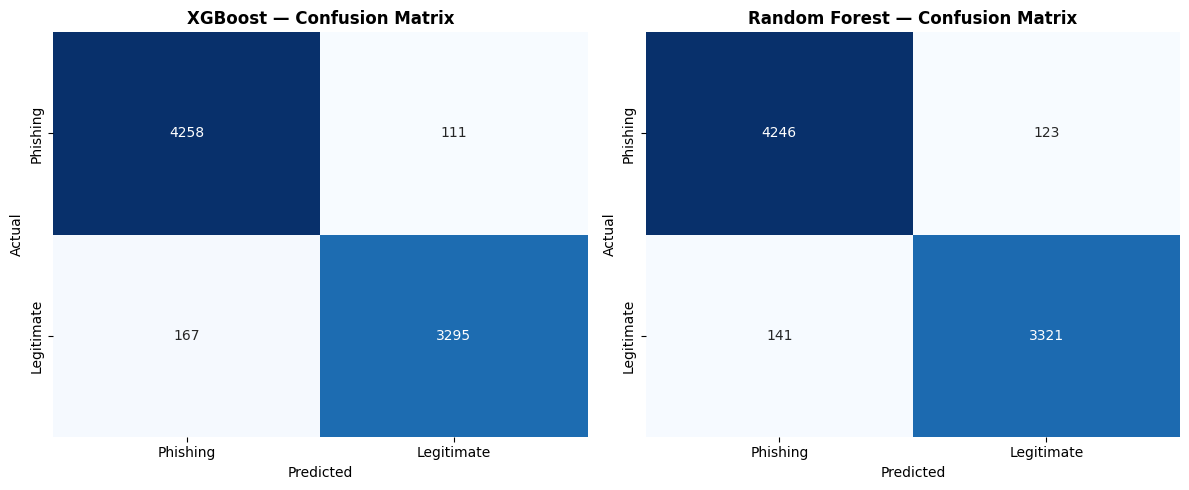

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

label_order = [1, 0]
label_names = ["Phishing", "Legitimate"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(axes, [("XGBoost", xgb_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_test, y_pred, labels=label_order)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=label_names, yticklabels=label_names, ax=ax
    )
    ax.set_title(f"{name} — Confusion Matrix", fontsize=12, weight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(output_dir / "email_confusion_matrices.png", dpi=300, bbox_inches="tight")
print("Saved confusion matrices to:", output_dir / "email_confusion_matrices.png")
plt.show()

## 6. ROC Curve Comparison

Both models' ROC curves plotted on the same axes for direct visual comparison, with AUC 
scores in the legend.

Saved ROC curve to: /kaggle/working/email_roc_curve.png


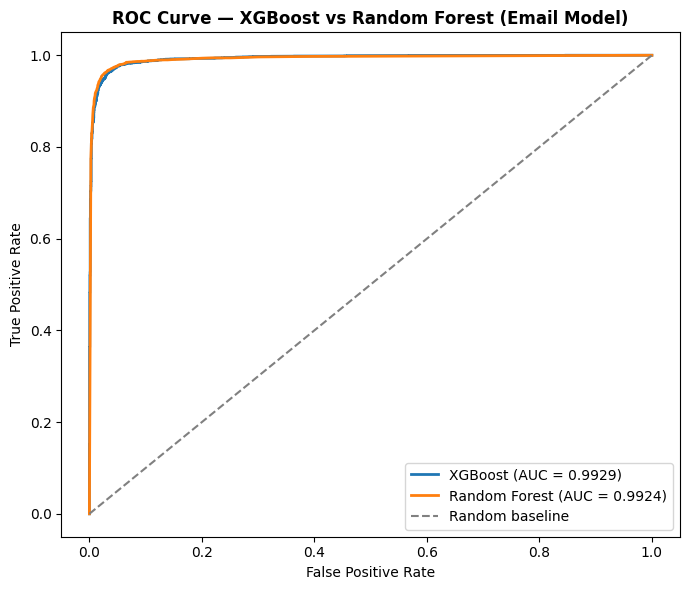

In [6]:
from sklearn.metrics import roc_curve

y_test_pos = (y_test == 1).astype(int)
xgb_score = xgb_proba if 1 == 1 else 1 - xgb_proba
rf_score = rf_proba if 1 == 1 else 1 - rf_proba

fpr_xgb, tpr_xgb, _ = roc_curve(y_test_pos, xgb_score)
fpr_rf, tpr_rf, _ = roc_curve(y_test_pos, rf_score)

plt.figure(figsize=(7, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {xgb_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost vs Random Forest (Email Model)", fontsize=12, weight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(output_dir / "email_roc_curve.png", dpi=300, bbox_inches="tight")
print("Saved ROC curve to:", output_dir / "email_roc_curve.png")
plt.show()

## 7. Precision-Recall Curve

Precision-recall curves for both models, focused on the phishing class. 
This view is often more informative than ROC on imbalanced data, since it directly shows the 
trade-off between catching phishing cases (recall) and avoiding false 
alarms (precision) — the trade-off that matters most for this project.

Saved precision-recall curve to: /kaggle/working/email_precision_recall_curve.png


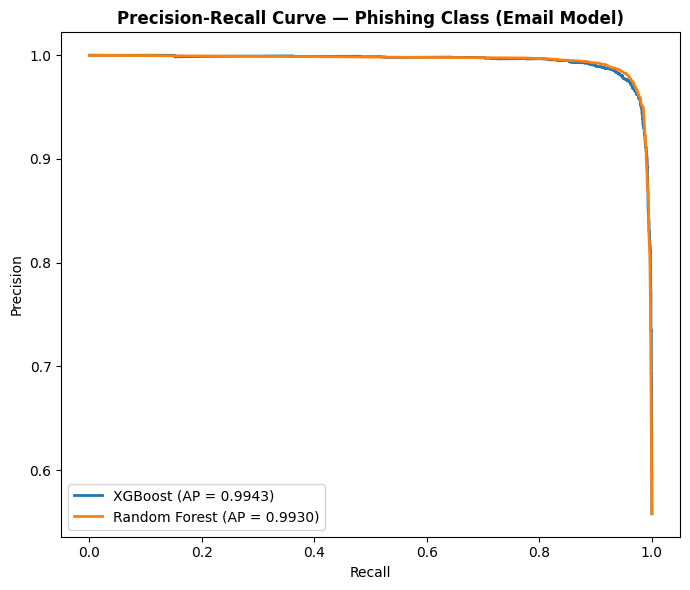

In [7]:
from sklearn.metrics import precision_recall_curve, average_precision_score

prec_xgb, rec_xgb, _ = precision_recall_curve(y_test_pos, xgb_score)
prec_rf, rec_rf, _ = precision_recall_curve(y_test_pos, rf_score)

ap_xgb = average_precision_score(y_test_pos, xgb_score)
ap_rf = average_precision_score(y_test_pos, rf_score)

plt.figure(figsize=(7, 6))
plt.plot(rec_xgb, prec_xgb, label=f"XGBoost (AP = {ap_xgb:.4f})", linewidth=2)
plt.plot(rec_rf, prec_rf, label=f"Random Forest (AP = {ap_rf:.4f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Phishing Class (Email Model)", fontsize=12, weight="bold")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig(output_dir / "email_precision_recall_curve.png", dpi=300, bbox_inches="tight")
print("Saved precision-recall curve to:", output_dir / "email_precision_recall_curve.png")
plt.show()

## 8. Export Summary

Final export of all evaluation artifacts — metrics table, both classification reports, and 
all three plots — collected into one place for direct use in the thesis chapter 4 write-up.

In [8]:
import json

summary = {
    "dataset": "Email",
    "positive_class": "Phishing",
    "test_set_size": int(len(y_test)),
    "metrics": metrics_df.to_dict(orient="index"),
}

with open(output_dir / "email_evaluation_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved evaluation summary to:", output_dir / "email_evaluation_summary.json")
print("\nAll evaluation artifacts saved to /kaggle/working:")
print(" -", "email_test_metrics.csv")
print(" -", "email_confusion_matrices.png")
print(" -", "email_roc_curve.png")
print(" -", "email_precision_recall_curve.png")
print(" -", "email_evaluation_summary.json")

Saved evaluation summary to: /kaggle/working/email_evaluation_summary.json

All evaluation artifacts saved to /kaggle/working:
 - email_test_metrics.csv
 - email_confusion_matrices.png
 - email_roc_curve.png
 - email_precision_recall_curve.png
 - email_evaluation_summary.json
